# 07. Feature ablation: проверяем, нужны ли все 20 признаков

**Цель:** найти минимальный набор признаков, который даёт RMSE в пределах +0.2°C от baseline (все 20).

**Подход:** обучаем ConvLSTM на 7 разных наборах фичей с урезанным бюджетом (30 эпох + ES), сравниваем val RMSE, выбираем меньший набор.

**Входы:**
- `data/tensor_01deg_v2.npz` — тензор (T, F, H, W) или (N, T, F, H, W)
- `data/y_new_rk_landcover.npz` — целевая MAGT/TTOP
- `src/model.py` — класс ConvLSTMNet

**Выходы:**
- `results/metrics/ablation_table.csv`
- `results/figures/ablation_comparison.png`
- `models/ablation/ablation_<name>.pt` — все обученные модели
- финальное переобучение победителя с полным бюджетом эпох

**Acceptance:** найдена конфигурация N<20 с RMSE в пределах +0.2°C от all_20.

In [2]:
# Environment auto-detection
# Работает на Colab VM, локальном Jupyter, и Colab UI с local runtime
import os
from pathlib import Path

IN_COLAB_VM = (
    'COLAB_RELEASE_TAG' in os.environ or
    'COLAB_GPU' in os.environ
)

if IN_COLAB_VM:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    BASE_DIR = Path('/content/drive/MyDrive/AI4Arctic')
    env_label = 'Colab VM'
else:
    # Local Jupyter (standalone ИЛИ Colab UI + local runtime)
    BASE_DIR = Path(os.environ.get(
        'AI4ARCTIC_HOME',
        Path.home() / 'Ai4Arctic'
    ))
    env_label = 'Local runtime'

print(f"Environment: {env_label}")
print(f"BASE_DIR: {BASE_DIR}")
assert BASE_DIR.exists(), f"BASE_DIR не найден: {BASE_DIR}. Установи AI4ARCTIC_HOME env var или скопируй проект в ~/Desktop/Ai4Arctic"

import sys
sys.path.insert(0, str(BASE_DIR))

Environment: Local runtime
BASE_DIR: /Users/dariazangirova/Ai4Arctic


In [3]:
# Setup: imports, device, paths
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

# Device: предпочитаем CUDA, затем MPS (Apple Silicon), иначе CPU
if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'
print(f"Device: {device}")

# Пути
DATA_DIR = BASE_DIR / 'data'
MODELS_DIR = BASE_DIR / 'models'
RESULTS_DIR = BASE_DIR / 'results'
METRICS_DIR = RESULTS_DIR / 'metrics'
FIGURES_DIR = RESULTS_DIR / 'figures'

for d in [MODELS_DIR, METRICS_DIR, FIGURES_DIR, MODELS_DIR / 'ablation']:
    d.mkdir(parents=True, exist_ok=True)

print(f"DATA_DIR: {DATA_DIR}")
print(f"MODELS_DIR: {MODELS_DIR}")

Device: mps
DATA_DIR: /Users/dariazangirova/Ai4Arctic/data
MODELS_DIR: /Users/dariazangirova/Ai4Arctic/models


## 1. Загружаем данные и сверяем имена фичей

In [4]:
import importlib
import inspect
import src.ablation
import src.reproducibility
importlib.reload(src.reproducibility)
importlib.reload(src.ablation)

from src.ablation import (
    FEATURE_NAMES,
    FEATURE_GROUPS,
    FINALIST_GROUP_NAMES,
    features_by_names,
    run_ablation_study,
    run_finalist_ablation,
    pick_ablation_winner,
    winner_features,
    plot_ablation_results,
)
from src.reproducibility import DEFAULT_SEED
from src.model import ConvLSTMNet  # импорт твоей модели

# Проверка: в ядре должна быть свежая версия ablation.py (с seed/n_repeats)
_sig = inspect.signature(run_ablation_study)
assert 'seed' in _sig.parameters, (
    "Старая версия src.ablation в памяти. Kernel → Restart, затем Run All с ячейки 1."
)
print(f"ablation.py OK: run_ablation_study{ _sig }")

print("Текущие имена признаков в src/ablation.py:")
for i, name in enumerate(FEATURE_NAMES):
    print(f"  [{i:2d}] {name}")
print(f"\nВсего: {len(FEATURE_NAMES)} признаков")
print(f"Если порядок отличается от твоего tensor — поправь FEATURE_NAMES в src/ablation.py!")

ablation.py OK: run_ablation_study(X_raw: 'np.ndarray', y_raw: 'np.ndarray', model_class, feature_groups: 'Dict[str, List[str]]' = None, train_targets: 'List[int]' = None, val_targets: 'List[int]' = None, epochs: 'int' = 30, device: 'str' = 'cuda', save_dir: 'Optional[Path]' = None, seed: 'int' = 42, n_repeats: 'int' = 1, deterministic: 'bool' = True) -> 'pd.DataFrame'
Текущие имена признаков в src/ablation.py:
  [ 0] NDVI
  [ 1] NDWI
  [ 2] NDMI
  [ 3] SAVI
  [ 4] LST_summer
  [ 5] LST_winter
  [ 6] LST_annual
  [ 7] FDD
  [ 8] TDD
  [ 9] snow_days
  [10] elevation
  [11] slope
  [12] aspect
  [13] soil_oc
  [14] soil_bd
  [15] soil_clay
  [16] MAAT
  [17] MAP
  [18] era5_temp
  [19] era5_precip

Всего: 20 признаков
Если порядок отличается от твоего tensor — поправь FEATURE_NAMES в src/ablation.py!


In [5]:
# Загружаем сырой тензор формата (T, H, W, F)
tensor_npz = np.load(DATA_DIR / 'tensor_01deg_v2.npz')
print("Ключи tensor:", list(tensor_npz.keys()))

X_raw = tensor_npz['X']             # (14, 231, 1501, 20)
feature_names_in_data = list(tensor_npz['feature_names'])
years = tensor_npz['years']
print(f"X shape: {X_raw.shape}  — формат (T, H, W, F)")
print(f"Years: {years}")
print(f"Feature names в тензоре: {feature_names_in_data}")

# Target
target_npz = np.load(DATA_DIR / 'y_new_rk_landcover.npz')
y_raw = target_npz['y_new']         # (14, 231, 1501) — в °C
print(f"\nTarget shape: {y_raw.shape}")
print(f"Target range: [{np.nanmin(y_raw):.2f}, {np.nanmax(y_raw):.2f}] °C")

# Sanity check: имена в FEATURE_NAMES совпадают с тензором?
mismatch = set(FEATURE_NAMES) ^ set(feature_names_in_data)
if mismatch:
    print(f"\nВНИМАНИЕ: расхождение между FEATURE_NAMES и тензором: {mismatch}")
else:
    print("\nFEATURE_NAMES совпадают с тензором.")


Ключи tensor: ['X', 'y', 'mask', 'lons', 'lats', 'years', 'feature_names']
X shape: (14, 231, 1501, 20)  — формат (T, H, W, F)
Years: [2010 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020 2021 2022 2023]
Feature names в тензоре: [np.str_('NDVI'), np.str_('NDWI'), np.str_('NDMI'), np.str_('SAVI'), np.str_('LST_summer'), np.str_('LST_winter'), np.str_('LST_annual'), np.str_('FDD'), np.str_('TDD'), np.str_('snow_days'), np.str_('elevation'), np.str_('slope'), np.str_('aspect'), np.str_('soil_oc'), np.str_('soil_bd'), np.str_('soil_clay'), np.str_('MAAT'), np.str_('MAP'), np.str_('era5_temp'), np.str_('era5_precip')]

Target shape: (14, 231, 1501)
Target range: [-16.29, 7.95] °C

FEATURE_NAMES совпадают с тензором.


## 3. Какие конфигурации сравним

| Группа | # фичей | Гипотеза |
|--------|---------|----------|
| `all_20` | 20 | baseline |
| `climate_core_6` | 6 | только top-6 температурных — нужны ли остальные? |
| `climate_wet_8` | 8 | climate + NDVI + NDWI |
| `climate_soil_9` | 9 | climate + snow + soil + MAP |
| `compact_12` | 12 | без landcover/rk и избыточных индексов |
| `no_soil_17` | 17 | без почвенных параметров |
| `no_lc_18` | 18 | без landcover/rk |

In [6]:
for name, feats in FEATURE_GROUPS.items():
    print(f"  {name:>20}: {len(feats):>2} фичей — {feats}")

                all_20: 20 фичей — ['NDVI', 'NDWI', 'NDMI', 'SAVI', 'LST_summer', 'LST_winter', 'LST_annual', 'FDD', 'TDD', 'snow_days', 'elevation', 'slope', 'aspect', 'soil_oc', 'soil_bd', 'soil_clay', 'MAAT', 'MAP', 'era5_temp', 'era5_precip']
        climate_core_6:  6 фичей — ['MAAT', 'LST_winter', 'TDD', 'LST_annual', 'FDD', 'era5_temp']
         climate_wet_8:  8 фичей — ['MAAT', 'LST_winter', 'TDD', 'LST_annual', 'FDD', 'era5_temp', 'NDVI', 'NDWI']
        climate_soil_9:  9 фичей — ['MAAT', 'LST_winter', 'TDD', 'LST_annual', 'FDD', 'era5_temp', 'snow_days', 'soil_oc', 'MAP']
            compact_12: 12 фичей — ['MAAT', 'LST_summer', 'LST_winter', 'LST_annual', 'era5_temp', 'TDD', 'FDD', 'NDVI', 'NDWI', 'snow_days', 'MAP', 'soil_oc']
            no_soil_17: 17 фичей — ['NDVI', 'NDWI', 'NDMI', 'SAVI', 'LST_summer', 'LST_winter', 'LST_annual', 'FDD', 'TDD', 'snow_days', 'elevation', 'slope', 'aspect', 'MAAT', 'MAP', 'era5_temp', 'era5_precip']
         no_terrain_17: 17 фичей — ['

## 4. Запускаем ablation

Воспроизводимость:
- `seed=42` — фиксирует инициализацию весов и порядок батчей
- `n_repeats=3` — три прогона на конфигурацию, в таблице mean ± std RMSE

ВНИМАНИЕ: на MPS ~25–35 мин на конфигурацию × `n_repeats` → **~9–12 часов** на 7 конфиг.
Для быстрой проверки поставь `n_repeats=1`.

In [7]:
# Воспроизводимый ablation: фиксированный seed + несколько повторов.
ABLATION_SEED = DEFAULT_SEED   # 42
N_REPEATS = 1                  # для быстрого теста: N_REPEATS = 1

results_df = run_ablation_study(
    X_raw=X_raw,
    y_raw=y_raw,
    model_class=ConvLSTMNet,
    feature_groups=FEATURE_GROUPS,
    train_targets=list(range(4, 13)),  # 2014..2022
    val_targets=[13],                   # 2023
    epochs=30,
    device=device,
    save_dir=MODELS_DIR / 'ablation',
    seed=ABLATION_SEED,
    n_repeats=N_REPEATS,
    deterministic=True,
)

results_df.to_csv(METRICS_DIR / 'ablation_table.csv', index=False)
cols = ['group', 'n_features', 'val_rmse_c', 'val_rmse_std', 'n_repeats', 'best_epoch', 'train_time_min']
print("\n=== Финальная таблица (отсортирована по mean val_rmse) ===")
print(results_df[[c for c in cols if c in results_df.columns]].to_string(index=False))



Конфигурация: all_20 (20 фичей)
    Train pairs: 2025, Val pairs: 225
    Epoch 0: train=0.3109, val=0.0685, val_rmse=1.372°C
    Epoch 5: train=0.1786, val=0.0505, val_rmse=1.178°C
    Epoch 10: train=0.1521, val=0.0345, val_rmse=0.974°C
    Epoch 15: train=0.1339, val=0.0297, val_rmse=0.904°C
    Early stop at epoch 16, best=8, val_rmse=1.011°C
  ИТОГ: val_rmse=0.794°C, best_epoch=8, time=3.5 мин

Конфигурация: climate_core_6 (6 фичей)
    Train pairs: 2025, Val pairs: 225
    Epoch 0: train=0.2757, val=0.0772, val_rmse=1.456°C
    Epoch 5: train=0.2086, val=0.0789, val_rmse=1.472°C
    Epoch 10: train=0.2001, val=0.0214, val_rmse=0.767°C
    Early stop at epoch 11, best=3, val_rmse=1.099°C
  ИТОГ: val_rmse=0.763°C, best_epoch=3, time=2.3 мин

Конфигурация: climate_wet_8 (8 фичей)
    Train pairs: 2025, Val pairs: 225
    Epoch 0: train=0.3218, val=0.0333, val_rmse=0.956°C
    Epoch 5: train=0.1966, val=0.0496, val_rmse=1.168°C
    Early stop at epoch 9, best=1, val_rmse=0.992°C
  И

## 4b. Head-to-head: только 6 vs 9 признаков (×3 повтора)

После быстрого скрининга всех 7 конфигураций (`N_REPEATS=1` в §4) уточняем только финалистов.
**2 конфигурации × 3 повтора ≈ 6 прогонов** (~2–3 ч на MPS), вместо 21 при полном ablation ×3.

In [8]:
# Head-to-head: climate_core_6 vs climate_soil_9
FINALIST_REPEATS = 3
FINALISTS_CSV = METRICS_DIR / 'ablation_finalists_6_9.csv'

finalists_df = run_finalist_ablation(
    X_raw=X_raw,
    y_raw=y_raw,
    model_class=ConvLSTMNet,
    group_names=FINALIST_GROUP_NAMES,  # ('climate_core_6', 'climate_soil_9')
    train_targets=list(range(4, 13)),
    val_targets=[13],
    epochs=30,
    device=device,
    save_dir=MODELS_DIR / 'ablation' / 'finalists',
    seed=ABLATION_SEED,
    n_repeats=FINALIST_REPEATS,
    deterministic=True,
)

finalists_df.to_csv(FINALISTS_CSV, index=False)
print(f"\nСохранено: {FINALISTS_CSV}")
print(finalists_df[['group', 'n_features', 'val_rmse_c', 'val_rmse_std', 'n_repeats']].to_string(index=False))

finalist_winner_name, finalist_winner_feats = winner_features(finalists_df)
print(f"\n=== Финалист-победитель (mean val RMSE, {FINALIST_REPEATS} повтора): {finalist_winner_name} ===")
for _, row in finalists_df.iterrows():
    print(f"  {row['group']:16s}  {row['val_rmse_c']:.3f} ± {row['val_rmse_std']:.3f} °C")


Конфигурация: climate_core_6 (6 фичей)
  --- Повтор 1/3 (seed=42) ---
    Train pairs: 2025, Val pairs: 225
    Epoch 0: train=0.2757, val=0.0772, val_rmse=1.456°C
    Epoch 5: train=0.2086, val=0.0789, val_rmse=1.472°C
    Epoch 10: train=0.2001, val=0.0214, val_rmse=0.767°C
    Early stop at epoch 11, best=3, val_rmse=1.099°C
      val_rmse=0.763°C, best_epoch=3
  --- Повтор 2/3 (seed=43) ---
    Train pairs: 2025, Val pairs: 225
    Epoch 0: train=0.2511, val=0.0575, val_rmse=1.257°C
    Epoch 5: train=0.2004, val=0.0537, val_rmse=1.215°C
    Epoch 10: train=0.1677, val=0.0737, val_rmse=1.423°C
    Epoch 15: train=0.1364, val=0.0395, val_rmse=1.041°C
    Early stop at epoch 16, best=8, val_rmse=1.397°C
      val_rmse=0.805°C, best_epoch=8
  --- Повтор 3/3 (seed=44) ---
    Train pairs: 2025, Val pairs: 225
    Epoch 0: train=0.2570, val=0.0729, val_rmse=1.416°C
    Epoch 5: train=0.1910, val=0.0681, val_rmse=1.368°C
    Epoch 10: train=0.1848, val=0.0248, val_rmse=0.825°C
    Epoch

## 5. Визуализация и выбор победителя

In [9]:
import pandas as pd
results_df = pd.read_csv(METRICS_DIR / 'ablation_table.csv')
print(results_df)

            group  n_features  \
0  climate_core_6           6   
1  climate_soil_9           9   
2          all_20          20   
3      compact_12          12   
4   climate_wet_8           8   
5      no_soil_17          17   
6   no_terrain_17          17   

                                            features  val_rmse_c  \
0       MAAT,LST_winter,TDD,LST_annual,FDD,era5_temp    0.763120   
1  MAAT,LST_winter,TDD,LST_annual,FDD,era5_temp,s...    0.771497   
2  NDVI,NDWI,NDMI,SAVI,LST_summer,LST_winter,LST_...    0.794480   
3  MAAT,LST_summer,LST_winter,LST_annual,era5_tem...    0.802180   
4  MAAT,LST_winter,TDD,LST_annual,FDD,era5_temp,N...    0.818125   
5  NDVI,NDWI,NDMI,SAVI,LST_summer,LST_winter,LST_...    0.859800   
6  NDVI,NDWI,NDMI,SAVI,LST_summer,LST_winter,LST_...    0.887680   

   val_rmse_std  n_repeats  seed_base  best_epoch  train_time_min  
0           0.0          1         42           3        2.281669  
1           0.0          1         42          10     

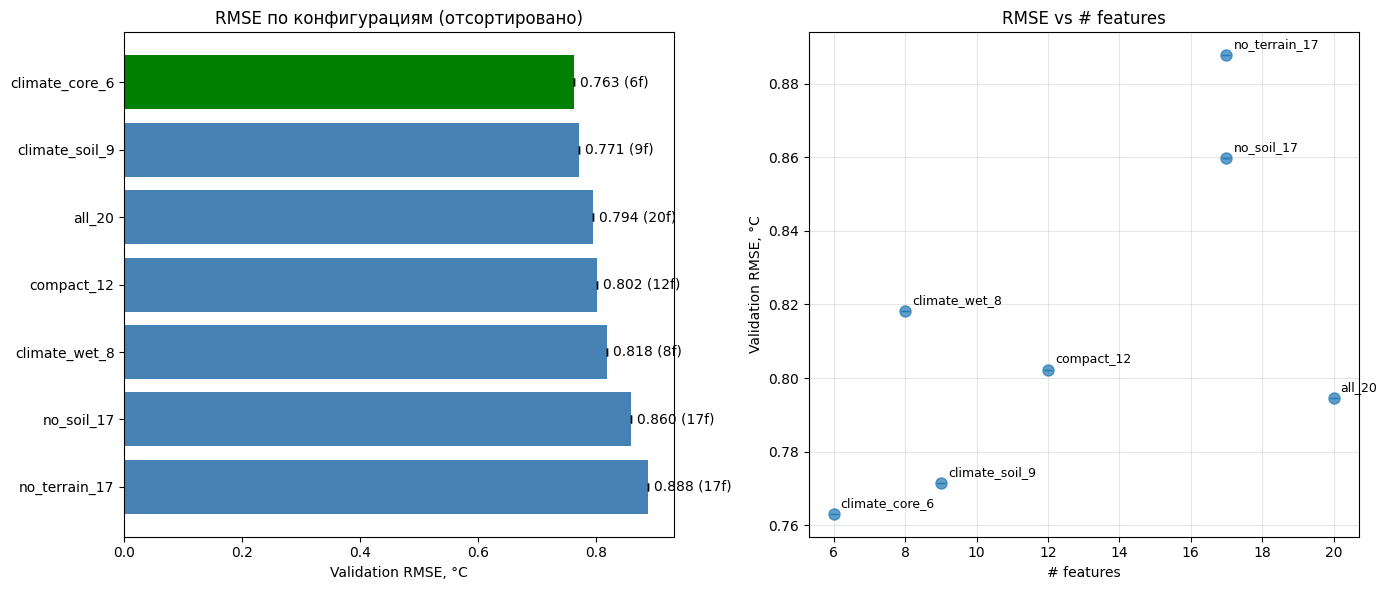


=== Победитель (лучший val RMSE): climate_core_6 ===
  # features: 6
  val RMSE: 0.763
  features: ['MAAT', 'LST_winter', 'TDD', 'LST_annual', 'FDD', 'era5_temp']

(Старое правило prefer_fewer=True дало бы: climate_core_6)


In [10]:
fig = plot_ablation_results(results_df, save_path=FIGURES_DIR / 'ablation_comparison.png')
plt.show()

# Победитель — лучший val RMSE (не минимальное число фичей)
winner_name, winner_feats = winner_features(results_df)
winner_row = results_df[results_df['group'] == winner_name].iloc[0]
print(f"\n=== Победитель (лучший val RMSE): {winner_name} ===")
print(f"  # features: {winner_row['n_features']}")
print(f"  val RMSE: {winner_row['val_rmse_c']:.3f}")
print(f"  features: {winner_feats}")

# Для справки: что выбрало бы старое правило parsimony
parsimony_name = pick_ablation_winner(results_df, prefer_fewer=True)
print(f"\n(Старое правило prefer_fewer=True дало бы: {parsimony_name})")

## 6. Финальное переобучение победителя с полным бюджетом

30 эпох — это для сравнения. Реальная модель должна обучаться столько же
эпох, сколько и baseline (по памяти проекта: best_epoch=20 при lr=1e-4, 80 эпох
с early stopping).

In [11]:
from src.ablation import features_by_names, train_one_config

FINALISTS_CSV = METRICS_DIR / 'ablation_finalists_6_9.csv'

# Если есть head-to-head 6 vs 9 (§4b) — берём победителя оттуда
if FINALISTS_CSV.exists():
    finalists_df = pd.read_csv(FINALISTS_CSV)
    winner_name, winner_feats = winner_features(finalists_df)
    print(f"Победитель из head-to-head (§4b): {winner_name}")
else:
    print(f"Победитель из полного ablation (§4): {winner_name}")

winner_indices = features_by_names(winner_feats)
print(f"Финальное переобучение для {winner_name} ({len(winner_indices)} фичей)...")

final_result = train_one_config(
    model_class=ConvLSTMNet,
    X_raw=X_raw,
    y_raw=y_raw,
    feature_indices=winner_indices,
    train_targets=list(range(4, 13)),  # 2014..2022
    val_targets=[13],                   # 2023
    epochs=80,                          # полный бюджет
    lr=1e-4,
    batch_size=8,
    device=device,
    early_stop_patience=15,
    seed=ABLATION_SEED,
    deterministic=True,
)

print(f"\nФинал: val_rmse={final_result['val_rmse']:.3f}°C, "
      f"best_epoch={final_result['best_epoch']}, "
      f"time={final_result['train_time_sec']/60:.1f} мин")

# Сохраняем финальную модель
final_model_path = MODELS_DIR / f'convlstm_ttop_rk_v2_{winner_name}.pt'
torch.save({
    'state_dict': final_result['model_state'],
    'feature_names': winner_feats,
    'feature_indices': winner_indices,
    'val_rmse_c': final_result['val_rmse'],
    'best_epoch': final_result['best_epoch'],
    'y_mean': final_result['y_mean'],
    'y_std': final_result['y_std'],
    'seed': ABLATION_SEED,
}, final_model_path)
print(f"Сохранено: {final_model_path}")


Победитель из head-to-head (§4b): climate_core_6
Финальное переобучение для climate_core_6 (6 фичей)...
    Train pairs: 2025, Val pairs: 225
    Epoch 0: train=0.2757, val=0.0772, val_rmse=1.456°C
    Epoch 5: train=0.2086, val=0.0789, val_rmse=1.472°C
    Epoch 10: train=0.2001, val=0.0214, val_rmse=0.767°C
    Epoch 15: train=0.1648, val=0.0287, val_rmse=0.889°C
    Early stop at epoch 18, best=3, val_rmse=1.002°C

Финал: val_rmse=0.763°C, best_epoch=3, time=3.5 мин
Сохранено: /Users/dariazangirova/Ai4Arctic/models/convlstm_ttop_rk_v2_climate_core_6.pt


## 7. Сравнение финальных метрик baseline vs winner

In [12]:
baseline_rmse = results_df[results_df['group'] == 'all_20']['val_rmse_c'].iloc[0]
ablation_rmse = winner_row['val_rmse_c']
delta_vs_baseline = final_result['val_rmse'] - baseline_rmse
delta_vs_ablation = final_result['val_rmse'] - ablation_rmse

print(f"Baseline (all_20, ablation 30 эпох): RMSE = {baseline_rmse:.3f}")
print(f"Winner  ({winner_name}, ablation 30 эпох): RMSE = {ablation_rmse:.3f}")
print(f"Winner  ({winner_name}, полный бюджет):  RMSE = {final_result['val_rmse']:.3f}")
print(f"Δ vs all_20: {delta_vs_baseline:+.3f} °C")
print(f"Δ vs ablation winner: {delta_vs_ablation:+.3f} °C")

print("\nИтог:")
print(f"  Лучшая конфигурация по val RMSE: {winner_name}")
print(f"  Признаков: {len(FEATURE_NAMES)} -> {len(winner_indices)} "
      f"({100*(1-len(winner_indices)/len(FEATURE_NAMES)):.0f}% сокращение)")
print(f"  Модель: models/convlstm_ttop_rk_v2_{winner_name}.pt")

Baseline (all_20, ablation 30 эпох): RMSE = 0.794
Winner  (climate_core_6, ablation 30 эпох): RMSE = 0.763
Winner  (climate_core_6, полный бюджет):  RMSE = 0.763
Δ vs all_20: -0.031 °C
Δ vs ablation winner: +0.000 °C

Итог:
  Лучшая конфигурация по val RMSE: climate_core_6
  Признаков: 20 -> 6 (70% сокращение)
  Модель: models/convlstm_ttop_rk_v2_climate_core_6.pt
